# Задание Pro
Самостоятельно напишите нейронную сеть, которая поможет распознавать болезни по симптомам. Используя подготовленную базу, создайте и обучите нейронную сеть, распознающую десять категорий
заболеваний: аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холицестит, эзофагит, энтерит, язва. Добейтесь правильного распознавания 6 и более заболеваний

Сразу обратим внимание датасет небольшой и хороших результатов добится  сложно.

Ссылка на датасет:https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [ ]:
# Скачаем архив с симптомами болезней
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip', None, quiet=True)

'diseases.zip'

In [ ]:
# Распакум архив
!unzip -o diseases.zip

Archive:  diseases.zip
   creating: dis/
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


In [ ]:
FILE_DIR  = 'dis/'                     # Папка с текстовыми файлами

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Зададим коэффициент разделения текста на обучающую и текстовую выборки
split_coef = 0.8

# Получим списки файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.') # Разделим имя файла и расширение
    class_name = m[0]        # Из имени файла получим название класса
    ext = m[1]               # Выделим расширение файла

    if ext=='txt':                                         # Если расширение txt то берем файл в работу
        if class_name not in CLASS_LIST:                   # Проверим, есть уже такой класс в списке
            print(f'Добавление класса "{class_name}"')     # Выведем имя нового класса
            CLASS_LIST.append(class_name)                  # Добавим новый класс в списоккласса "{class_name}"')

        cls = CLASS_LIST.index(class_name)                                        # Получим индекс (номер) нового класса
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')      # Сообщим о появлении нового класса

        with open(f'{FILE_DIR}/{file_name}', 'r') as f: # Откроем файл на чтение
            text = f.read()                                                       # Загрузка содержимого файла в строку
            text = text.replace('\n', ' ').split(' ')                             # Уберем символы перевода строк, получим список слов
            text_len=len(text)                                                    # Найдем количество прочитанных слов
            text_train.append(' '.join(text[:int(text_len*split_coef)]))          # Выделим часть файла в обучающую выборку
            text_test.append(' '.join(text[int(text_len*split_coef):]))           # Выделим часть файла в тестовую выборку



Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"
Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"
Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"


In [ ]:
# Найдем получившееся количество классов
CLASS_COUNT = len(CLASS_LIST)

In [ ]:
# Выведем число получившихся классов
print(CLASS_COUNT)

10


In [ ]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):             # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')     # Выведем имя класса
    print(f'  train: {text_train[cls]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Дуоденит
  train: боль в эпигастральной области, тошнота, рвота,  общая слабость,  болезненность при пальпации в эпигастральной области,  слабость, повышение температуры.   дискомфорт и боль в верхних отделах живота, повышенная утомляемость,  снижение физических и умственных способностей, раздражительность, слабость, капризность,  головокружения, боль в голове, тошнота, рвота, отрыжка,  Учащенное сердцебиение, снижение аппетита, метеоризм, вздутие живота  боль в эпигастральной области, тошнота, рвота,  общая слабость,  болезненность при пальпации в эпигастральной области  сильная тошнота,  частая и обильная рвота, слабость быстрая утомляемость,  боль в подложечной области   боль или чувство дискомфорта в области желудка,  тошнота и рвота; потеря аппетита; желудочные кровотечения   Болевые ощущения в подложечной области; Быстрая утомляемость, слабость,  головокружение; Повышение температуры; Отсутствие аппетита; Неприятный привкус во рту; Тошнота, газообразование,  чувство перепо

In [ ]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [ ]:
#ваше решение
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

VOCAB_SIZE = 10000
WIN_SIZE = 120
WIN_HOP = 30

def split_sequence(sequence, win_size, hop):
    return [
        sequence[i:i + win_size]
        for i in range(0, len(sequence) - win_size + 1, hop)
    ]

def vectorize_sequence(seq_list, win_size, hop):
    x = []
    y = []

    for cls in range(CLASS_COUNT):
        vectors = split_sequence(seq_list[cls], win_size, hop)

        x.extend(vectors)
        y.extend([utils.to_categorical(cls, CLASS_COUNT)] * len(vectors))

    return np.array(x), np.array(y)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, lower=True, split=' ', oov_token='неизвестное_слово')

tokenizer.fit_on_texts(text_train)

seq_train = tokenizer.texts_to_sequences(text_train)

x_all, y_all = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)

x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42, stratify=y_all.argmax(axis=1))

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

x_train: (148, 120)
y_train: (148, 10)
x_test: (38, 120)
y_test: (38, 10)


In [ ]:
model = Sequential()

model.add(Embedding(VOCAB_SIZE, 64, input_length=WIN_SIZE))

model.add(Conv1D(64, 3, activation='relu'))
model.add(GlobalMaxPooling1D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True,)

history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 676ms/step - accuracy: 0.1014 - loss: 2.2966 - val_accuracy: 0.1842 - val_loss: 2.2663
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2500 - loss: 2.2357 - val_accuracy: 0.5526 - val_loss: 2.2269
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3784 - loss: 2.1935 - val_accuracy: 0.6053 - val_loss: 2.1847
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3649 - loss: 2.1486 - val_accuracy: 0.6316 - val_loss: 2.1416
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4730 - loss: 2.0820 - val_accuracy: 0.6053 - val_loss: 2.0910
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5068 - loss: 2.0112 - val_accuracy: 0.6053 - val_loss: 2.0311
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5203 - loss: 1.9610 - val_accuracy: 0.5789 - val_loss: 1.9609
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5946 - loss: 1.8455 - val_accuracy: 0.5789 - val_loss: 1.8797

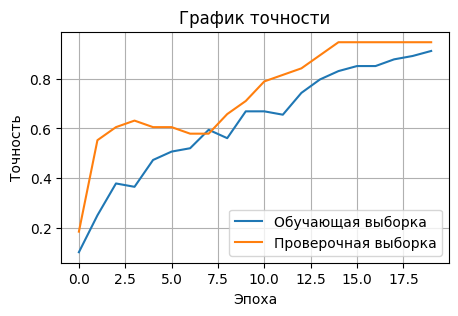

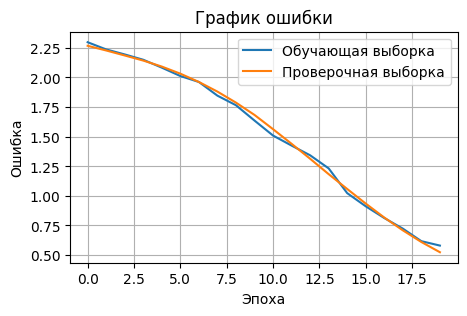

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('График точности')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.title('График ошибки')
plt.legend()
plt.grid(True)
plt.show()